# Notebook 02 — Analyse Exploratoire des Données (EDA)

**Objectif** : Explorer les données pour comprendre les caractéristiques des clients qui churned  
et identifier les variables les plus pertinentes pour la prédiction.

Ce notebook couvre :
- Distribution des variables
- Comparaison churn vs non-churn
- Heatmap de corrélation
- Identification des variables les plus importantes

## 0. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Chargement des données

On charge le dataset brut pour les visualisations (labels lisibles)  
et le dataset nettoyé pour l'analyse de corrélation.

In [2]:
# Dataset brut — pour les graphiques avec de vrais labels
df_raw = pd.read_csv("../data/raw/telco_customer_churn.csv")

# Dataset nettoyé — pour la corrélation
df_clean = pd.read_csv("../data/processed/cleaned_telco.csv")

print("Dataset brut :", df_raw.shape)
print("Dataset nettoyé :", df_clean.shape)

Dataset brut : (7043, 21)
Dataset nettoyé : (7043, 31)


## 2. Distribution des variables

On regarde comment les données sont réparties pour chaque variable clé.

### 2.1 Variables démographiques

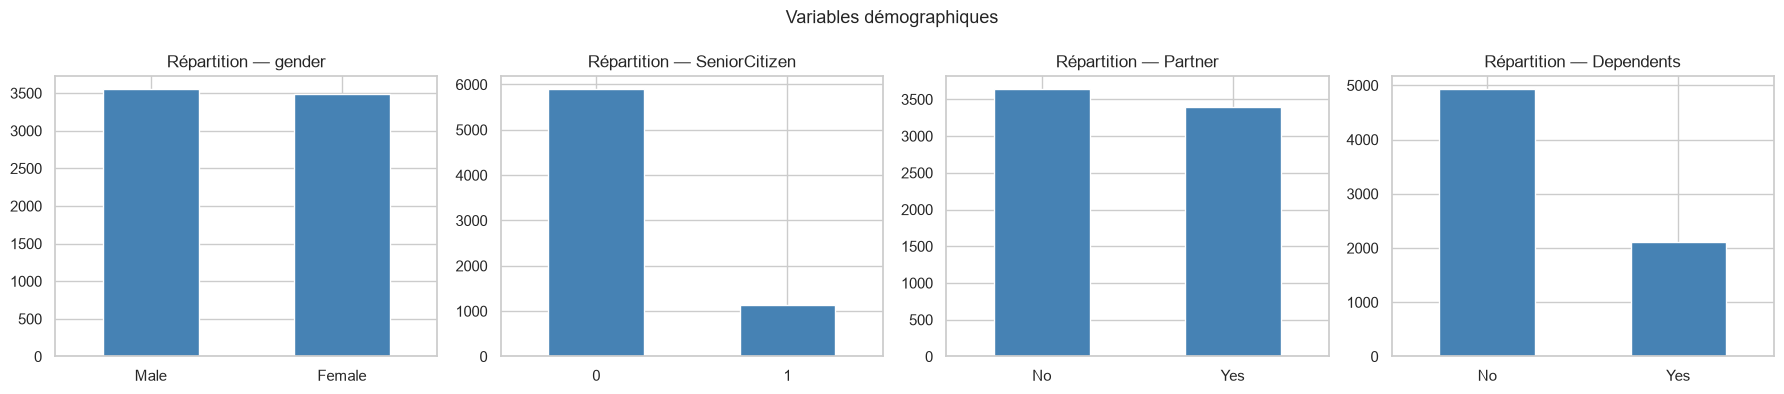

In [3]:
variables_demo = ["gender", "SeniorCitizen", "Partner", "Dependents"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(variables_demo):
    df_raw[col].astype(str).value_counts().plot(
        kind="bar", ax=axes[i], color="steelblue", edgecolor="white"
    )
    axes[i].set_title(f"Répartition — {col}")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=0)

plt.suptitle("Variables démographiques", fontsize=13)
plt.tight_layout()
plt.show()

### 2.2 Services souscrits

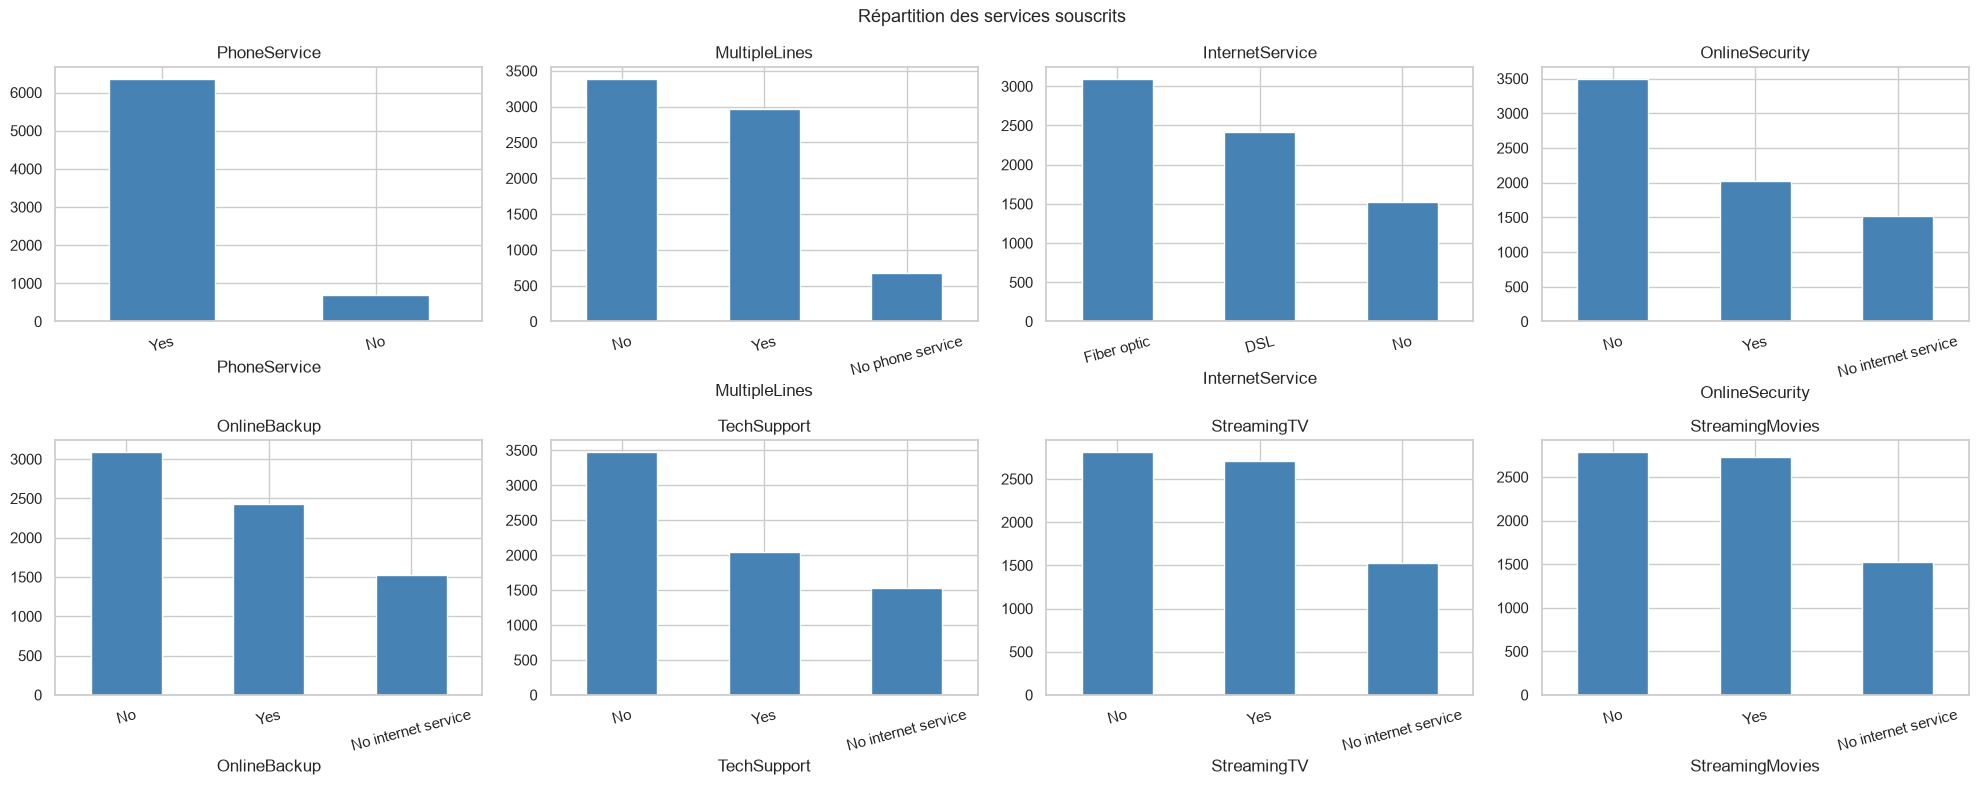

In [4]:
variables_services = [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "TechSupport",
    "StreamingTV", "StreamingMovies"
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(variables_services):
    df_raw[col].value_counts().plot(
        kind="bar", ax=axes[i], color="steelblue", edgecolor="white"
    )
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=15)

plt.suptitle("Répartition des services souscrits", fontsize=13)
plt.tight_layout()
plt.show()

### 2.3 Informations du compte client

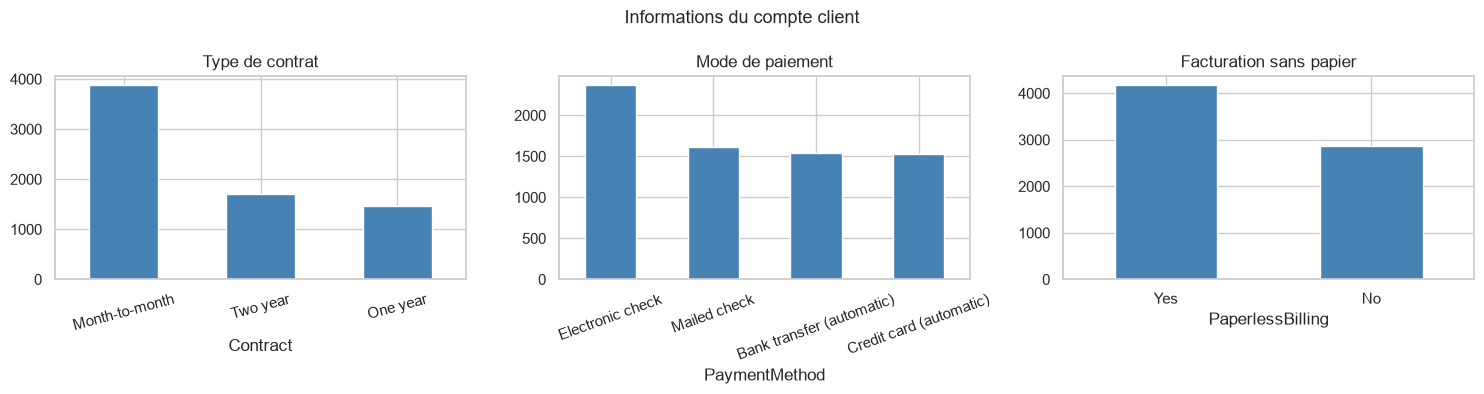

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Type de contrat
df_raw["Contract"].value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Type de contrat")
axes[0].tick_params(axis="x", rotation=15)

# Mode de paiement
df_raw["PaymentMethod"].value_counts().plot(
    kind="bar", ax=axes[1], color="steelblue", edgecolor="white"
)
axes[1].set_title("Mode de paiement")
axes[1].tick_params(axis="x", rotation=20)

# Facturation sans papier
df_raw["PaperlessBilling"].value_counts().plot(
    kind="bar", ax=axes[2], color="steelblue", edgecolor="white"
)
axes[2].set_title("Facturation sans papier")
axes[2].tick_params(axis="x", rotation=0)

plt.suptitle("Informations du compte client", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Comparaison Churn vs Non-Churn

On cherche quelles variables sont différentes entre les clients qui ont churné  
et ceux qui sont restés.

### 3.1 Ancienneté (tenure)

C:\Users\Adamo\AppData\Local\Temp\ipykernel_48436\3672598793.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


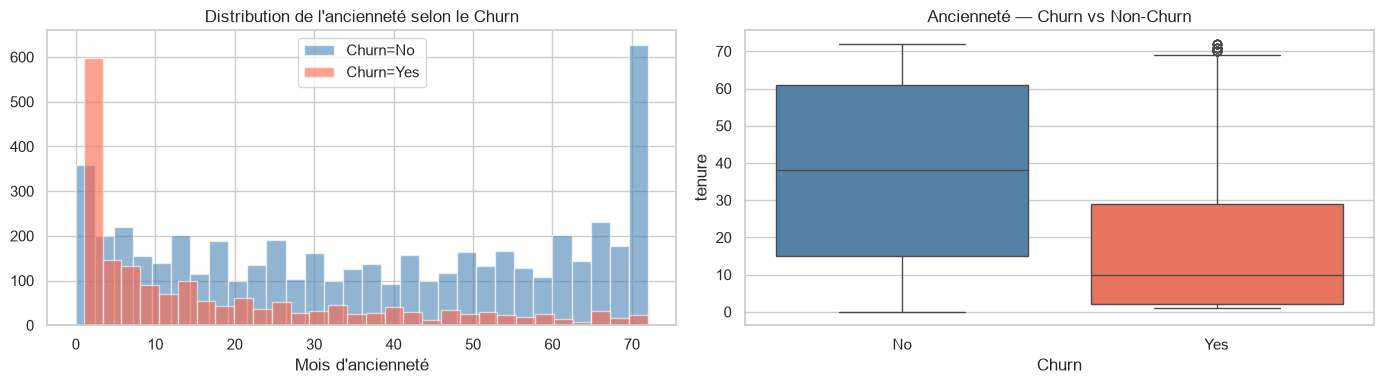

Ancienneté moyenne — Non-Churn : 37.6 mois
Ancienneté moyenne — Churn     : 18.0 mois


In [6]:
# Les clients qui churned ont-ils une ancienneté plus courte ?
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogramme par groupe
for label, color in [("No", "steelblue"), ("Yes", "tomato")]:
    df_raw[df_raw["Churn"] == label]["tenure"].hist(
        bins=30, ax=axes[0], alpha=0.6, color=color, label=f"Churn={label}", edgecolor="white"
    )
axes[0].set_title("Distribution de l'ancienneté selon le Churn")
axes[0].set_xlabel("Mois d'ancienneté")
axes[0].legend()

# Boxplot
sns.boxplot(
    data=df_raw, x="Churn", y="tenure", ax=axes[1],
    palette={"No": "steelblue", "Yes": "tomato"}
)
axes[1].set_title("Ancienneté — Churn vs Non-Churn")

plt.tight_layout()
plt.show()

print("Ancienneté moyenne — Non-Churn :", df_raw[df_raw["Churn"] == "No"]["tenure"].mean().round(1), "mois")
print("Ancienneté moyenne — Churn     :", df_raw[df_raw["Churn"] == "Yes"]["tenure"].mean().round(1), "mois")

### 3.2 Frais mensuels (MonthlyCharges)

C:\Users\Adamo\AppData\Local\Temp\ipykernel_48436\2174804483.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


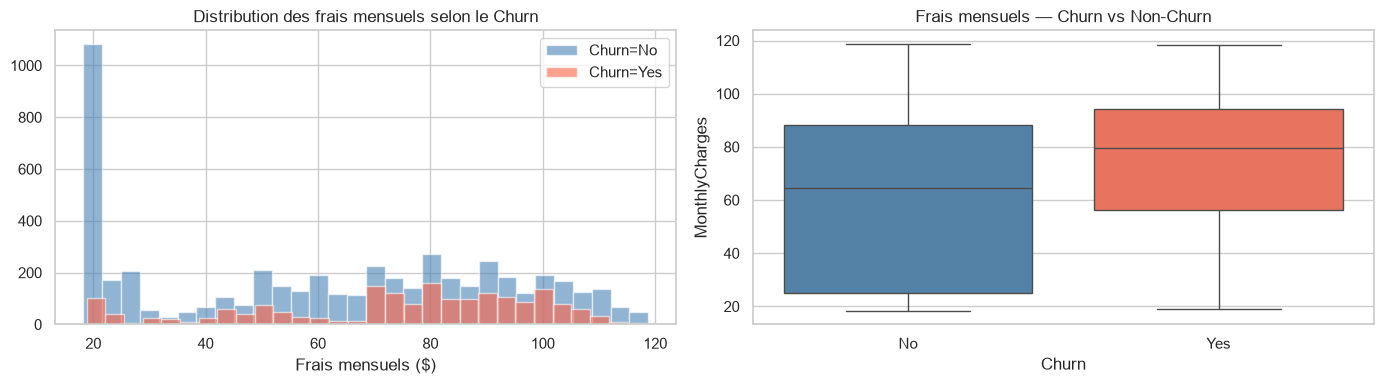

Frais moyens — Non-Churn : 61.27 $
Frais moyens — Churn     : 74.44 $


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color in [("No", "steelblue"), ("Yes", "tomato")]:
    df_raw[df_raw["Churn"] == label]["MonthlyCharges"].hist(
        bins=30, ax=axes[0], alpha=0.6, color=color, label=f"Churn={label}", edgecolor="white"
    )
axes[0].set_title("Distribution des frais mensuels selon le Churn")
axes[0].set_xlabel("Frais mensuels ($)")
axes[0].legend()

sns.boxplot(
    data=df_raw, x="Churn", y="MonthlyCharges", ax=axes[1],
    palette={"No": "steelblue", "Yes": "tomato"}
)
axes[1].set_title("Frais mensuels — Churn vs Non-Churn")

plt.tight_layout()
plt.show()

print("Frais moyens — Non-Churn :", df_raw[df_raw["Churn"] == "No"]["MonthlyCharges"].mean().round(2), "$")
print("Frais moyens — Churn     :", df_raw[df_raw["Churn"] == "Yes"]["MonthlyCharges"].mean().round(2), "$")

### 3.3 Type de contrat

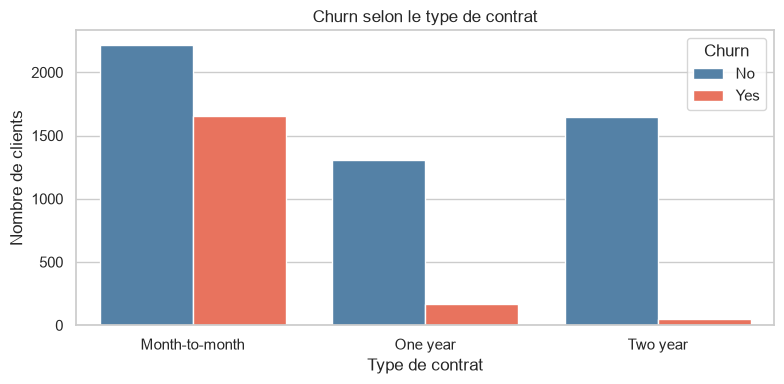

In [8]:
# Le type de contrat est souvent le meilleur prédicteur du churn
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df_raw, x="Contract", hue="Churn",
    palette={"No": "steelblue", "Yes": "tomato"}
)
plt.title("Churn selon le type de contrat")
plt.xlabel("Type de contrat")
plt.ylabel("Nombre de clients")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

### 3.4 Service Internet

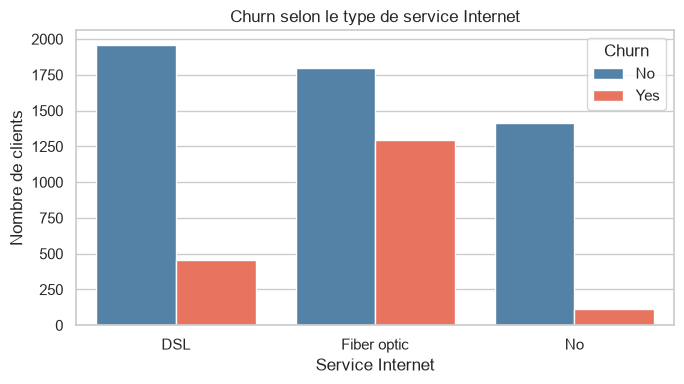

In [9]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df_raw, x="InternetService", hue="Churn",
    palette={"No": "steelblue", "Yes": "tomato"}
)
plt.title("Churn selon le type de service Internet")
plt.xlabel("Service Internet")
plt.ylabel("Nombre de clients")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

### 3.5 Clients seniors

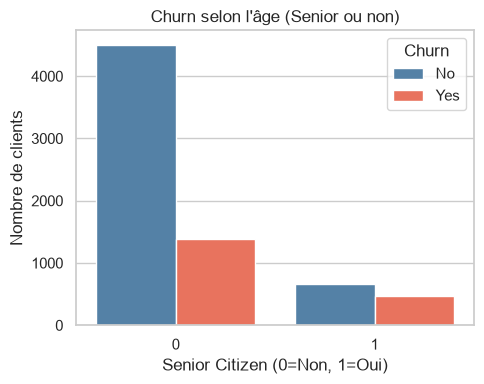

In [10]:
plt.figure(figsize=(5, 4))
sns.countplot(
    data=df_raw, x="SeniorCitizen", hue="Churn",
    palette={"No": "steelblue", "Yes": "tomato"}
)
plt.title("Churn selon l'âge (Senior ou non)")
plt.xlabel("Senior Citizen (0=Non, 1=Oui)")
plt.ylabel("Nombre de clients")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

## 4. Heatmap de corrélation

On utilise le dataset nettoyé (encodé) pour calculer  
la corrélation entre toutes les variables et la cible Churn.

In [11]:
# Corrélation de chaque variable avec Churn
correlation_churn = df_clean.corr()["Churn"].drop("Churn").sort_values(ascending=False)

print("Top 10 variables positivement corrélées avec le Churn :")
print(correlation_churn.head(10).round(3))
print()
print("Top 10 variables négativement corrélées avec le Churn :")
print(correlation_churn.tail(10).round(3))

Top 10 variables positivement corrélées avec le Churn :
InternetService_Fiber optic       0.308
PaymentMethod_Electronic check    0.302
MonthlyCharges                    0.193
PaperlessBilling                  0.192
SeniorCitizen                     0.151
StreamingTV_Yes                   0.063
StreamingMovies_Yes               0.061
MultipleLines_Yes                 0.040
PhoneService                      0.012
gender_Male                      -0.009
Name: Churn, dtype: float64

Top 10 variables négativement corrélées avec le Churn :
TotalCharges                           -0.198
InternetService_No                     -0.228
StreamingTV_No internet service        -0.228
OnlineSecurity_No internet service     -0.228
OnlineBackup_No internet service       -0.228
DeviceProtection_No internet service   -0.228
StreamingMovies_No internet service    -0.228
TechSupport_No internet service        -0.228
Contract_Two year                      -0.302
tenure                                 -0.352

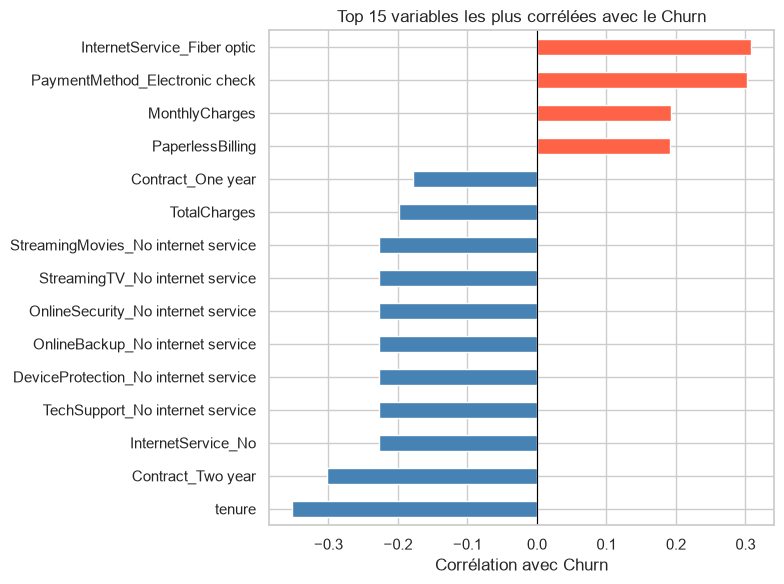

In [12]:
# Visualisation des 15 variables les plus corrélées avec Churn
top_correlations = correlation_churn.abs().sort_values(ascending=False).head(15)
top_cols = top_correlations.index.tolist()

plt.figure(figsize=(8, 6))
correlation_churn[top_cols].sort_values().plot(
    kind="barh",
    color=["tomato" if v > 0 else "steelblue" for v in correlation_churn[top_cols].sort_values()]
)
plt.title("Top 15 variables les plus corrélées avec le Churn")
plt.xlabel("Corrélation avec Churn")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

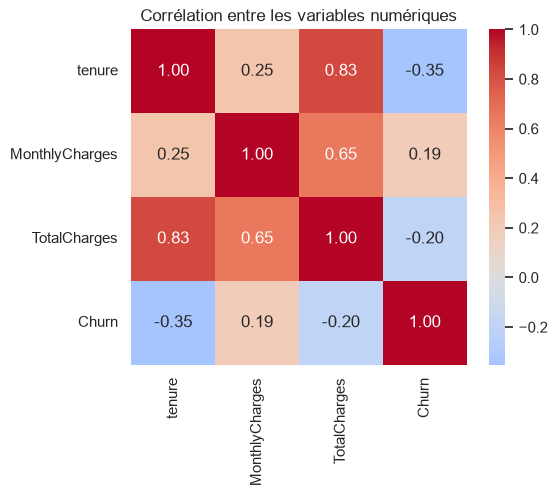

In [13]:
# Heatmap des variables numériques principales
variables_principales = ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    df_clean[variables_principales].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Corrélation entre les variables numériques")
plt.tight_layout()
plt.show()

## 5. Variables les plus importantes

On identifie les variables à retenir en priorité pour les modèles.

In [14]:
# On garde les variables avec une corrélation absolue > 0.1
seuil = 0.1
variables_importantes = correlation_churn[correlation_churn.abs() > seuil].index.tolist()

print(f"Variables avec corrélation > {seuil} avec Churn ({len(variables_importantes)}) :")
for var in variables_importantes:
    print(f"  {var} : {correlation_churn[var]:.3f}")

Variables avec corrélation > 0.1 avec Churn (21) :
  InternetService_Fiber optic : 0.308
  PaymentMethod_Electronic check : 0.302
  MonthlyCharges : 0.193
  PaperlessBilling : 0.192
  SeniorCitizen : 0.151
  PaymentMethod_Credit card (automatic) : -0.134
  Partner : -0.150
  Dependents : -0.164
  TechSupport_Yes : -0.165
  OnlineSecurity_Yes : -0.171
  Contract_One year : -0.178
  TotalCharges : -0.198
  InternetService_No : -0.228
  StreamingTV_No internet service : -0.228
  OnlineSecurity_No internet service : -0.228
  OnlineBackup_No internet service : -0.228
  DeviceProtection_No internet service : -0.228
  StreamingMovies_No internet service : -0.228
  TechSupport_No internet service : -0.228
  Contract_Two year : -0.302
  tenure : -0.352


## Conclusion

Les principaux enseignements de cette analyse :

**Variables les plus liées au churn :**
- **tenure** (négatif) : les clients récents churned beaucoup plus
- **Contract** : les contrats mois-à-mois ont un taux de churn très élevé
- **InternetService (Fiber optic)** : les clients fibre churned plus que les autres
- **MonthlyCharges** (positif) : des frais élevés augmentent le risque de churn
- **OnlineSecurity / TechSupport** (négatif) : les clients avec ces services churned moins

**Déséquilibre de classes** : ~26% de churners — les modèles devront en tenir compte.